# **Урок 5**. Сегментируем что угодно

Из лекции мы с вами узнали, что, используя модель ```SAM (Segment Anything)```, мы можем с помощью кликов, боксов и текстовых промптов получать маски каких угодно объектов. Грех этим не воспользоваться, давайте разберемся с тем, как на практике устроена работа с ```SAM```.

## **План**

1. Смотрим и тыкаем демку на сайте
2. Готовим всё необходимое для работы
3. Генерируем маски автоматически
4. Генерируем маски с помощью кликов (точек)
5. Генерируем маски с помощью боксов

## **1. Смотрим и тыкаем демку на сайте**

Материалы в этой практике сделаны на основе кода из [официального репозитория](https://github.com/facebookresearch/segment-anything). Там же есть ссылка на официальное интерактивное [демо](https://segment-anything.com/demo). Давайте потыкаем в него и посмотрим, какие на деле у ```SAM``` есть возможности. 

Итак, в демо мы увидели, что можно:
1. Выделять маски объектов по клику
2. Расширять и сужать маски объектов с помощью позитивных/негативных кликов
3. Выделять маски объектов по боксу
4. Уточнять эти маски, опять же, с помощью кликов
5. Сегментировать все возможные объекты автоматически
6. А вот сегментации по тексту в этих реализациях так и нет

Демо хорошо подходит для проверки работоспособности, но настоящие датасеты мы с его помощью размечать, конечно, не будем. Давайте теперь поработаем с ```SAM``` по-настоящему.  

## **2. Готовим всё необходимое для работы**

Установим библиотеку и скачаем чекпоинт модели. В [разделе чекпоинтов](https://github.com/facebookresearch/segment-anything/tree/main?tab=readme-ov-file#model-checkpoints) их три, но этот самый большой и дефолтный.  

In [1]:
%pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-wm5wh91j
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-wm5wh91j
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
#!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [3]:
import cv2
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
from segment_anything.utils.transforms import ResizeLongestSide

In [4]:
def show_masks(anns):
    # если масок нет, ничего не делаем
    if len(anns) == 0:
        return
    # иначе сортируем их по площади
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    
    # создаем массив из 1 размера фото, но с 4 каналами
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0 
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask

    return img

In [5]:
# возьмем картинку для теста
image = cv2.imread('images/dog.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

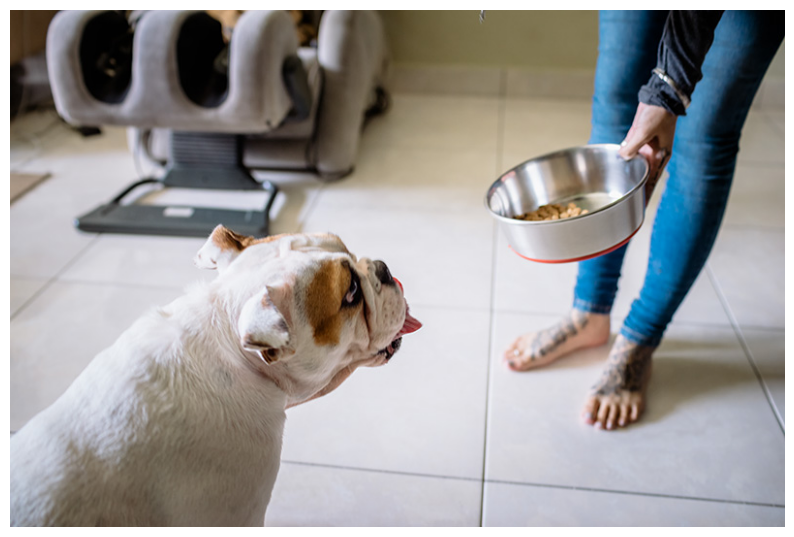

In [6]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()

## 3. Генерируем маски автоматически

Поскольку SAM умеет эффективно обрабатывать промпты, маски для всего изображения могут быть сгенерированы путем семплирования большого количества промптов по изображению. Этот метод использовался для генерации датасета для ```SAM```.

Класс `SamAutomaticMaskGenerator` это и делает. Он семплирует промпты-точки по сетке на изображении, из каждой из которых SAM может предсказать несколько масок. Затем маски фильтруются по качеству и дедуплицируются с использованием NMS. 

In [7]:
# выбираем архитектуру, путь до чекпоинта и девайс
sam_checkpoint = 'sam_vit_h_4b8939.pth'
model_type = 'vit_h'
device = 'cuda'

# создаем модель
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# создаем генератор масок
mask_generator = SamAutomaticMaskGenerator(sam)

/ssd/a.belozerova/usr/anaconda3/envs/torch24/lib/python3.11/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch

In [8]:
# пробуем генерировать
masks = mask_generator.generate(image)

Генератор вернет нам список масок, где каждая маска — это ```dict``` с такими ключами:
* `segmentation` : сама маска
* `area` : площадь маски в пикселях
* `bbox` : бокс вокруг маски в формате XYWH
* `predicted_iou` : оценка моделью качества маски 
* `point_coords` : промпты-точки, по которым получилась эта маска 
* `stability_score` : ещё одна оценка качества
* `crop_box` : бокс, в рамках которого генерировалась эта маска, формат XYWH

In [9]:
# посмотрим, что у нам нагенерировалось
print(len(masks))
print(masks[0].keys())

66
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


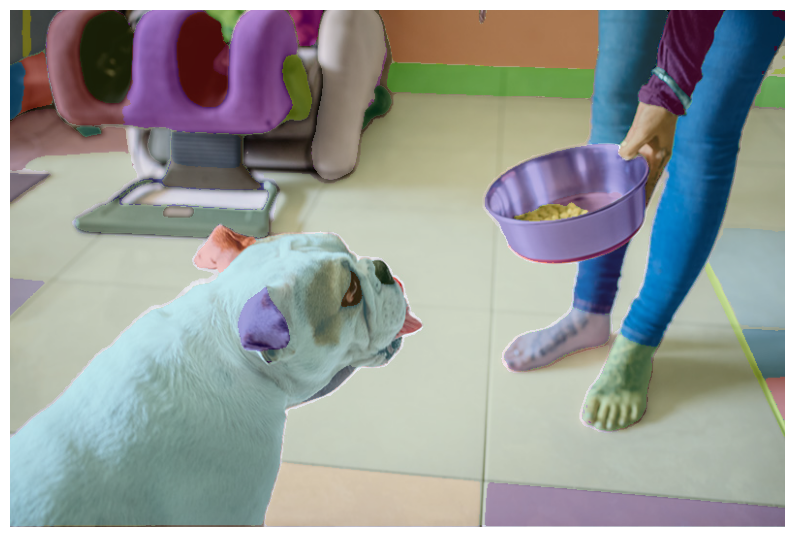

In [10]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.imshow(show_masks(masks))
plt.axis('off')
plt.show() 

Выглядит классно, но кажется, что кое-где лишнее поотделялось. 

Можем ли мы как-то настроить работу автоматического генератора?

Да, можем. 

У генератора есть несколько настраиваемых параметров, которые управляют плотностью выборки точек и пороговыми значениями для удаления низкокачественных или дублирующих масок. Кроме того, генерация может автоматически запускаться на кропах из изображения для повышения производительности на более мелких объектах, а постобработка может удалять случайные пиксели и дыры. Вот пример конфигурации, которая сгенерирует больше масок:

In [11]:
# Аргументы описаны тут https://github.com/facebookresearch/segment-anything/blob/main/segment_anything/automatic_mask_generator.py#L35
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam, 
    points_per_side=32, 
    pred_iou_thresh=0.86, 
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)

In [12]:
masks2 = mask_generator_2.generate(image)
print(len(masks2))

90


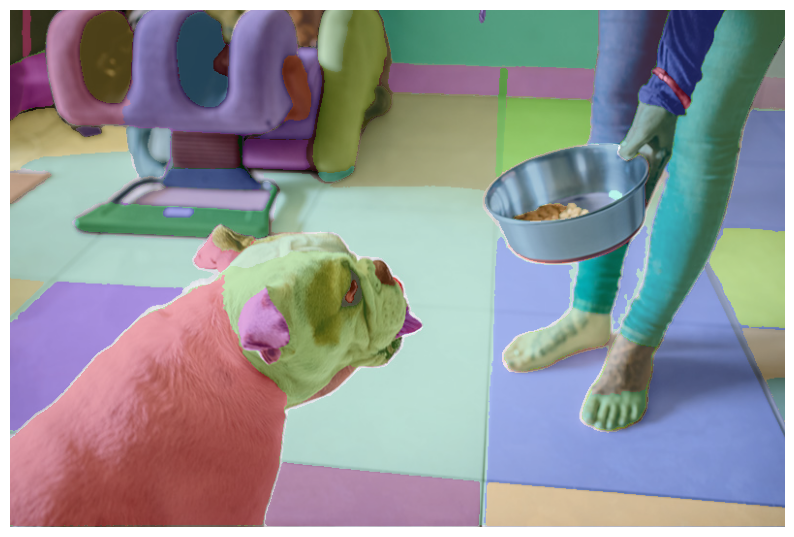

In [13]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.imshow(show_masks(masks2))
plt.axis('off')
plt.show() 

А вот пример, порождающий меньше масок:

In [14]:
# Аргументы описаны тут https://github.com/facebookresearch/segment-anything/blob/main/segment_anything/automatic_mask_generator.py#L35
mask_generator_3 = SamAutomaticMaskGenerator(
    model=sam, 
    points_per_side=16, 
    pred_iou_thresh=0.97, 
    stability_score_thresh=0.97,
    crop_n_layers=0,
    crop_n_points_downscale_factor=0,
    min_mask_region_area=100,
)

In [15]:
masks3 = mask_generator_3.generate(image)
print(len(masks3))

16


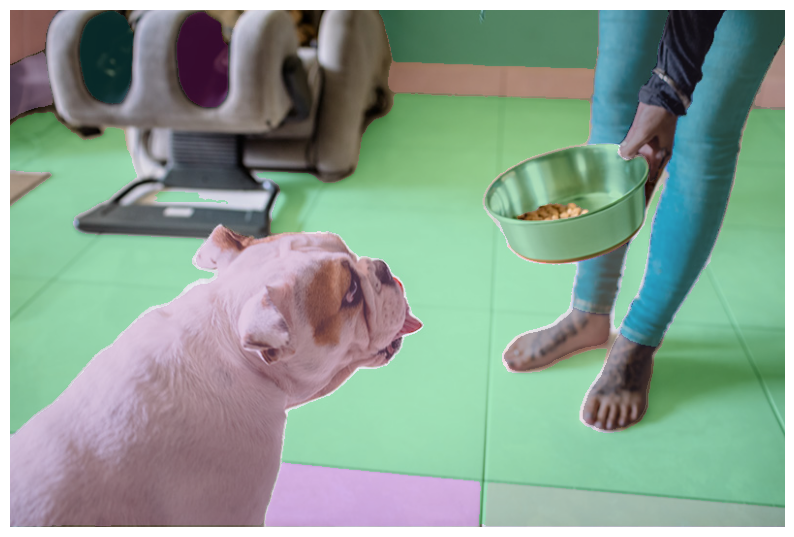

In [16]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.imshow(show_masks(masks3))
plt.axis('off')
plt.show() 

Давайте все результаты рядом сравним:

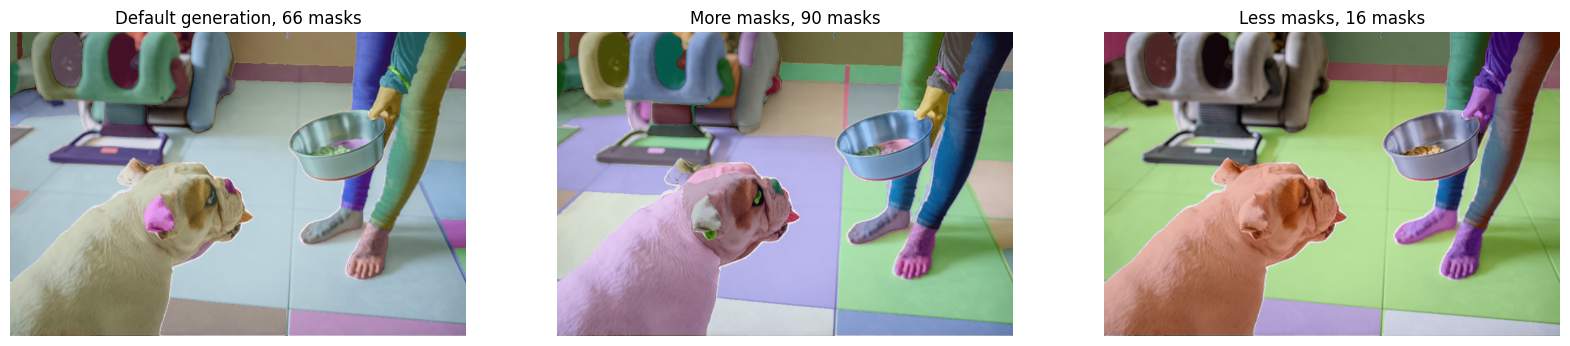

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20, 15))
ax[0].imshow(image)
ax[1].imshow(image)
ax[2].imshow(image)

ax[0].imshow(show_masks(masks))
ax[1].imshow(show_masks(masks2))
ax[2].imshow(show_masks(masks3))

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

ax[0].set_title(f'Default generation, {len(masks)} masks')
ax[1].set_title(f'More masks, {len(masks2)} masks')
ax[2].set_title(f'Less masks, {len(masks3)} masks')
plt.show()

Итак, тут мы узнали, что
- можно почти ничего не делать и сегментировать все объекты на картинке;
- можно поварьировать параметры генерации (всякие пороги) и таким образом влиять на число и крупность получаемых масок.

Но вообще, сегментировать все подряд хоть и выглядит круто, но не очень полезно. Обычно мы хотим сегментировать что-то конкретно нам нужное. Давайте это и попробуем сделать.

# **4. Генерируем маски с помощью кликов (точек)**

Вспомним, как устроен ```SAM```:
- ```image encoder``` получает на вход картинку и вычисляет для неё эмбеддинг;
- если уже были маски на прошлой итерации, то их обрабатывает ```mask encoder```;
- ```prompt encoder``` получает на вход промпт одного из поддерживаемых типов;
- всё это фьюзится, и с помощью ```mask decoder``` предсказываются три маски.

<p align="center">
  <a href="images/model_diagram.png"><img src="images/model_diagram.png" style="width:100%; height:50%;"/></a>
</p>

Для того чтобы работать с промптами, в библиотеке предусмотрен класс ```SamPredictor```. 

Сперва в нем надо задать изображение с помощью метода ```set_image```, который вычисляет эмбеддинг, а затем подавать промпты с помощью метода ```predict```.

In [18]:
# зададим вспомогательные функции для отрисовки масок, точек, боксов
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))    

In [19]:
# и возьмем новую картинку для работы
image = cv2.imread('images/truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

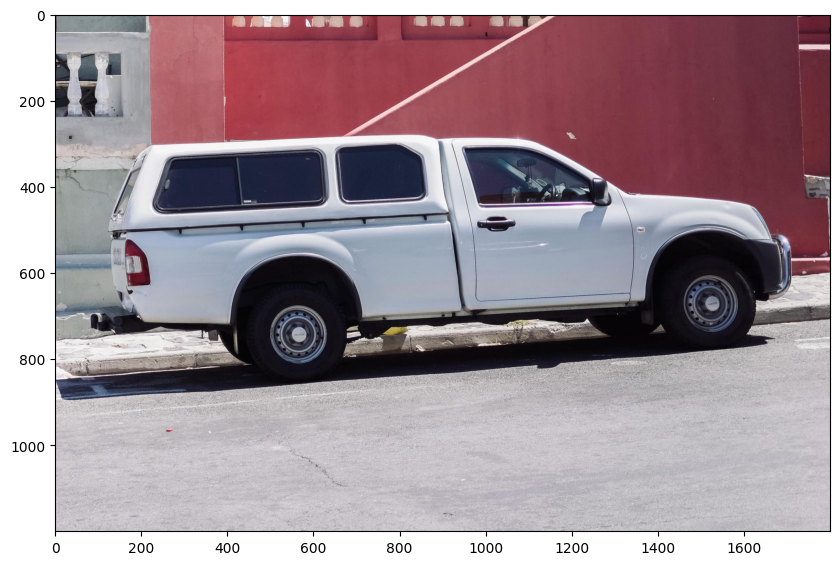

In [20]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

Сперва надо загрузить модель ```SAM``` (что мы уже сделали выше) и создать для него не генератор, а предиктор:

In [21]:
predictor = SamPredictor(sam)

Задаем изображение, чтобы посчитать для него эмбеддинг один раз и запомнить его:

In [22]:
predictor.set_image(image)

Далее нам надо задать клик — просто точку `(x, y)` и её класс - либо 1 для объектов, то есть это будет позитивный клик, либо 0 для фона (негативный клик), если с помощью этой точки маску мы хотим уменьшать. 

Мы можем сразу использовать несколько точек, но попробуем с одной начать. 

In [23]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

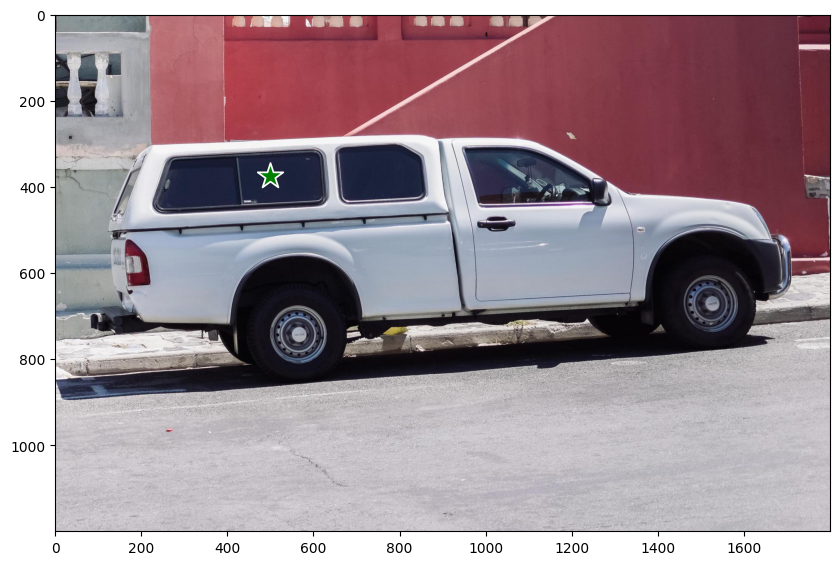

In [24]:
# посмотрим, где расположена наша позитивная точка
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()  

Теперь получим предсказания масок с помощью метода ```predict```, на выходе будем иметь:
-  ```masks``` — список масок
- ```scores``` — предсказываемые моделью скоры, по сути оценка качества. **Не** лежит в диапазоне [0, 1]
- ```logits``` — логиты маски, которые можно использовать в качестве входа для следующих итераций:

In [25]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True, # если тут True, то будет 3 маски, это дефолтное состояние, иначе будет одна
)

In [26]:
masks.shape  # (number_of_masks) x H x W

(3, 1200, 1800)

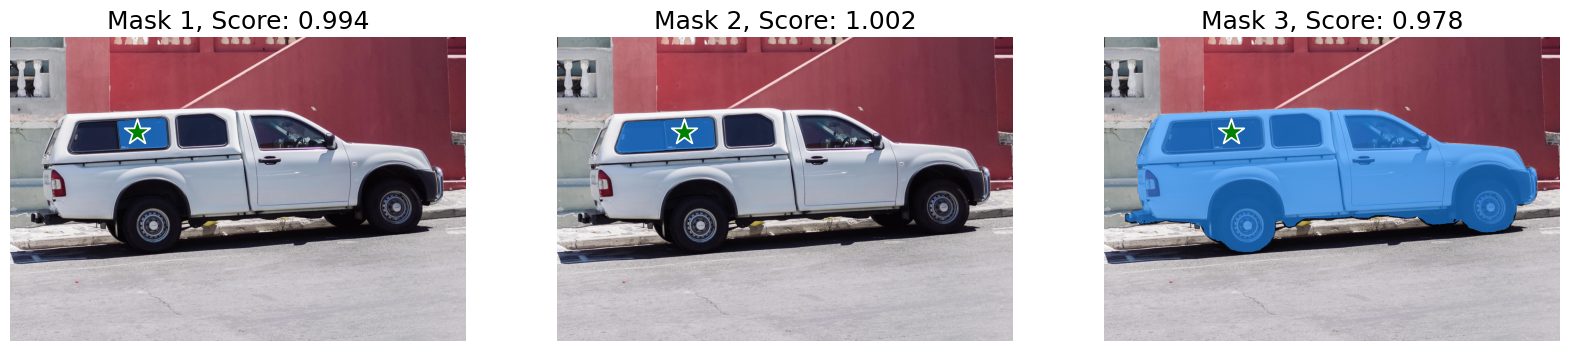

In [27]:
# сравним три полученные маски
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

for i, (mask, score) in enumerate(zip(masks, scores)):
    ax[i].imshow(image)
    show_mask(mask, ax[i])
    show_points(input_point, input_label, ax[i])
    ax[i].set_title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    ax[i].axis('off')

plt.show()  

В целом кажется очень удобным, что сеть предоставляет выбор из масок: 
- если нам нужна машина, мы возьмем маску с самой большой площадью
- если нам нужно окно, то можно ориентироваться на скор или на самую маленькую площадь

А если для уточнения положения можно использовать несколько точек, 

In [28]:
# теперь наши промпты — две позитивные точки
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 1])

# а также маска с самым большим скором
mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [29]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :], # новый аргумент для маски
    multimask_output=False, # хотим одну на выходе
)

In [30]:
masks.shape

(1, 1200, 1800)

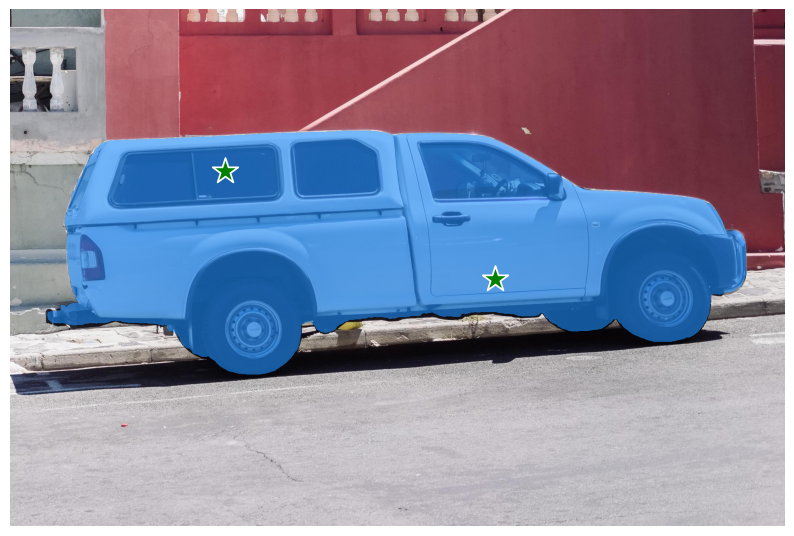

In [31]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show() 

Супер, вторая точка помогла нам выделить машину полностью и однозначно. 

Если же мы, наоборот, хотели бы выбрать окно, то можно было бы вторую точку сделать негативной:

In [32]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 0]) # вот тут только класс точки поменяли

mask_input = logits[np.argmax(scores), :, :] 

In [33]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

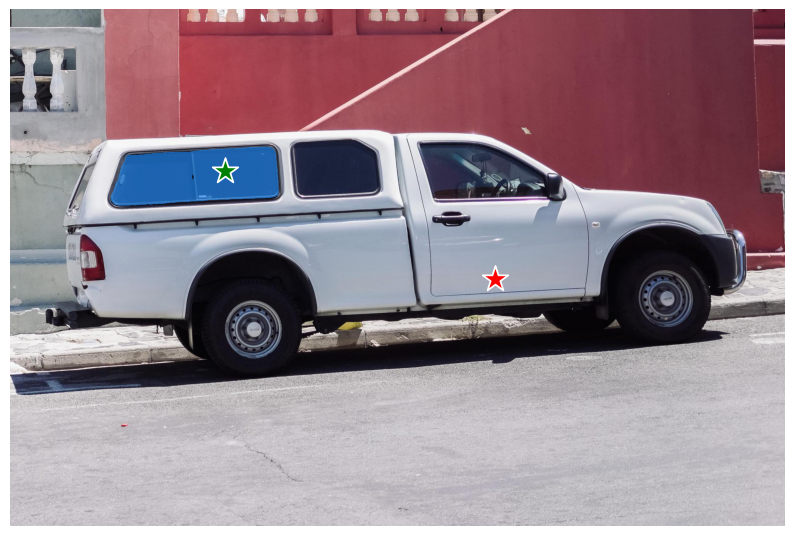

In [34]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show() 

Всё получилось, как и ожидали. Таким образом, за два шага в зависимости от класса второй точки мы смогли выбрать нужные нам маски: либо всей машины, либо только её окна. 

А в целом мы тут поняли:
- как подать точки в качестве промптов
- что точки-промпты бывают разных классов - позитивные/негативные
- что для последовательной сегментации изображения мы, кроме промптов, подаем в предиктор ещё и предыдущую маску

## **5. Генерируем маски с помощью боксов**

Конечно, в качестве промпта можно подать и бокс в формате ```[x1, y1, x2, y2]```:

In [35]:
input_box = np.array([425, 600, 700, 875])

In [36]:
masks, _, _ = predictor.predict(
    point_coords=None, # теперь точек нет
    point_labels=None,
    box=input_box[None, :], # бокс появился
    multimask_output=False,
)

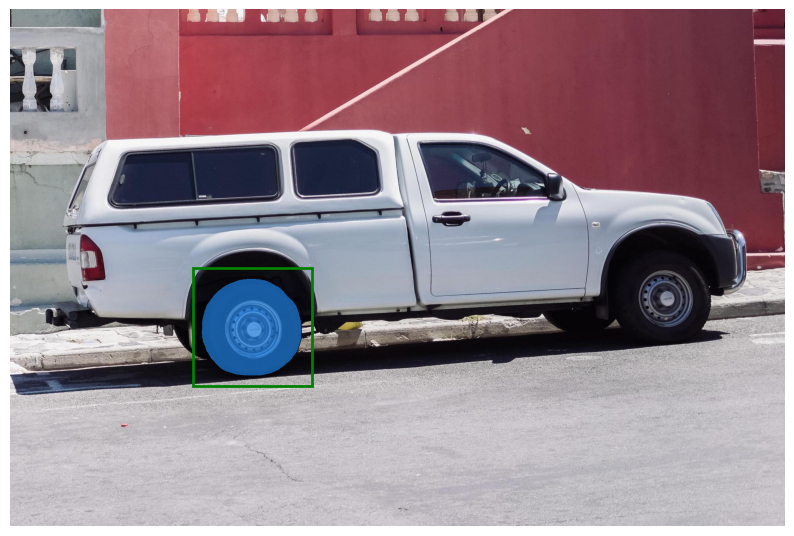

In [37]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()

Боксы могут быть только положительными, тут уже возможности корректировать маску другими боксами нет. 

Зато можно комбинировать боксы и точки, давайте посмотрим как:

In [38]:
# зададим бокс и негативную точку
input_box = np.array([425, 600, 700, 875])
input_point = np.array([[575, 750]])
input_label = np.array([0])

In [39]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

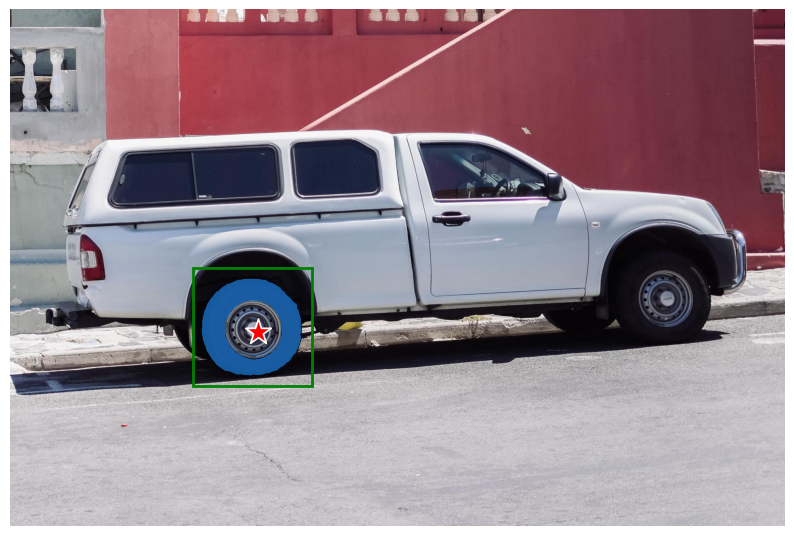

In [40]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

С негативной точкой посередине нам удалось выделить только шину, исключив диски (а позитивная точка бы ничего не изменила).

Также мы можем подавать сразу несколько боксов на вход с помощью метода `predict_torch`. 

Тут только важно, чтобы точки и боксы на входе были `torch`-тензорами и лежали на целевом девайсе:

In [41]:
input_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=predictor.device)

In [42]:
transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])

Этот трансформ можно найти в [`segment_anything.utils.transforms`](https://github.com/facebookresearch/segment-anything/blob/main/segment_anything/utils/transforms.py).

In [43]:
# и теперь подаем в метод predict_torch
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes, # тут теперь аргумент boxes вместо box
    multimask_output=False,
)

In [44]:
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

torch.Size([4, 1, 1200, 1800])

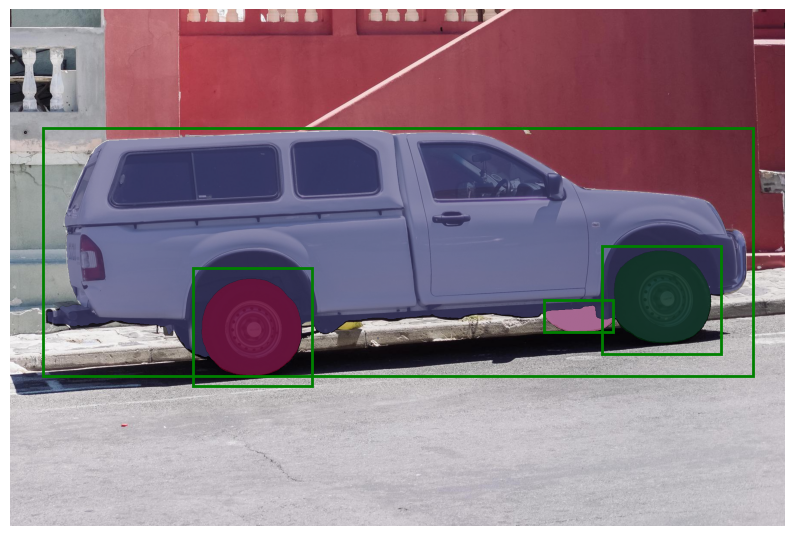

In [45]:
# смотрим, что получилось

plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()

И в целом, если нас интересует не интерактивная сегментация шаг за шагом, а автоматизированная за один шаг (скорее всего так будет почти всегда), то можно все картинки и промпты к ним объединять в батчи и обрабатывать картинки одновременно:

In [46]:
image1 = image  
image1_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=sam.device)


image2 = cv2.imread('images/groceries.jpg')
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image2_boxes = torch.tensor([
    [450, 170, 520, 350],
    [350, 190, 450, 350],
    [500, 170, 580, 350],
    [580, 170, 640, 350],
], device=sam.device)

Все входы тогда надо упаковать в `dict`-ы следующего вида:
* `image`: картинка, PyTorch tensor, в формате `CHW`
* `original_size`: оригинальный размер, формат `(H, W)`
* `point_coords`: тензор из точек-промптов
* `point_labels`: тензор классов для точек-промптов
* `boxes`: тензор из боксов-промптов
* `mask_inputs`: тензор из масок (если есть)


In [47]:
# для картинок готовим трансформ
resize_transform = ResizeLongestSide(sam.image_encoder.img_size)

def prepare_image(image, transform, device):
    image = transform.apply_image(image)
    image = torch.as_tensor(image, device=device.device) 
    return image.permute(2, 0, 1).contiguous()

In [48]:
# готовим батч из dict-ов
batched_input = [
     {
         'image': prepare_image(image1, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image1_boxes, image1.shape[:2]),
         'original_size': image1.shape[:2]
     },
     {
         'image': prepare_image(image2, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image2_boxes, image2.shape[:2]),
         'original_size': image2.shape[:2]
     }
]

И запускаем модель:

In [49]:
batched_output = sam(batched_input, multimask_output=False)

Выход модели - это тоже список с результатами по каждой картинке в батче, результат — это `dict` с такими ключами:
-  `masks` — torch тензоры с бинарными масками в размере оригинального изображения
- `iou_predictions` — некоторые скоры уверенности
- `low_res_logits` — logit-ы масок, которые можно дальше использовать (но мы не будем)

In [50]:
batched_output[0].keys()

dict_keys(['masks', 'iou_predictions', 'low_res_logits'])

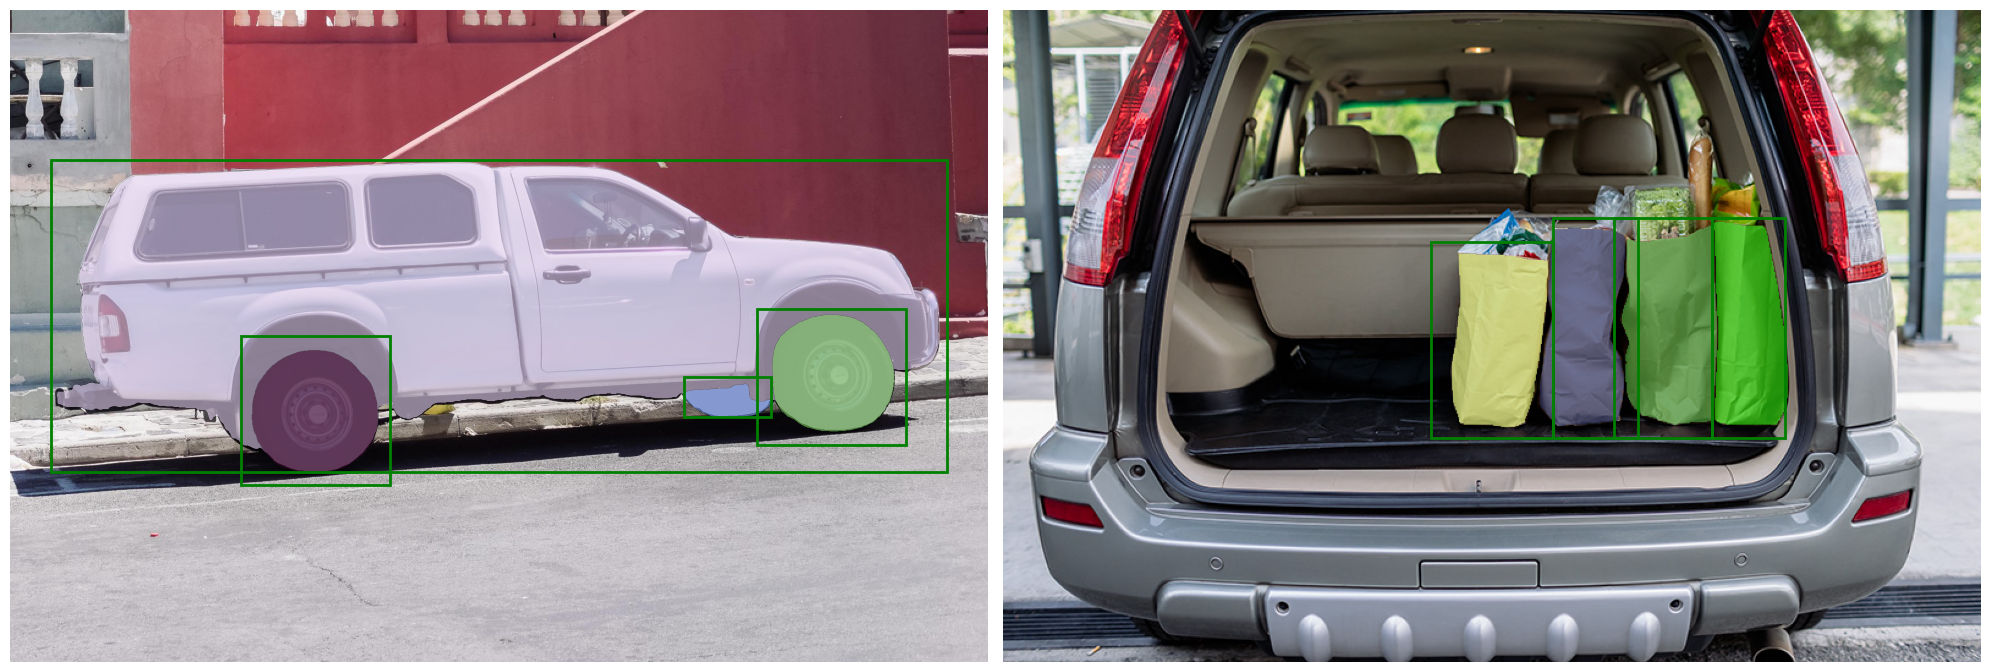

In [51]:
# и давайте отрисуем получившиеся результаты
fig, ax = plt.subplots(1, 2, figsize=(20, 20))

ax[0].imshow(image1)
for mask in batched_output[0]['masks']:
    show_mask(mask.cpu().numpy(), ax[0], random_color=True)
for box in image1_boxes:
    show_box(box.cpu().numpy(), ax[0])
ax[0].axis('off')

ax[1].imshow(image2)
for mask in batched_output[1]['masks']:
    show_mask(mask.cpu().numpy(), ax[1], random_color=True)
for box in image2_boxes:
    show_box(box.cpu().numpy(), ax[1])
ax[1].axis('off')

plt.tight_layout()
plt.show()

Круто. Значит, если для какого-то датасета у нас уже есть боксы объектов, то маски для них получить с помощью `SAM` — вообще не вопрос. 

Если же у нас никакой разметки нет, надо будет придумывать что-то более интересное для задания определенных точек-промптов. Но это уже вопрос для вашей будущей карьеры CV-инженера ;)

## **Итоги**

Итак,  мы
1. Посмотрели на реальные возможности `SAM` с помощью демо на сайте
2. Узнали, как получить автоматическую сегментацию всех масок и как её можно настраивать
3. Научились взаимодействовать с позитивными и негативными точками-промптами
4. Узнали, как взаимодействовать с боксами-промптами и смесью разнотипных промптов
5. Разобрались, как обрабатывать одновременно батчи картинок и промптов к ним

Ну это ли не чудо?

Кстати, у `SAM` только-только (на момент создания этого ноутбука) вышла версия 2! 🔥

Найти её можно в [официальном репозитории](https://github.com/facebookresearch/segment-anything-2), и эта версия умеет сегментировать видео, анализируя сразу последовательность кадров. 

Очень круто, обязательно поиграйтесь!

А мы на этом завершаем блок практики по уроку 5, 

See you!